### OPERATORNORM WITHOUT ADJOINT 

- Creator:  Jonas Bresch, M.Sc
- Date: February 14rd, 2025

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc

# from cbx.dynamics import CBO 
# from cbx.dynamics import CBXDynamic

import imp

In [41]:
import adjointfreenorm
imp.reload(adjointfreenorm)

<module 'adjointfreenorm' from '/Users/jonasbresch/Desktop/operator_missmatch/finale/adjointfreenorm.py'>

In [3]:
A = np.random.randn(10,50)
V = np.random.randn(50,10)

In [5]:
np.max(np.linalg.svdvals(A - V.T))

np.float64(14.064338320890043)

In [20]:
_, _, vu_sol, _, _, vuval, _, _, listbc_uv, _, _, _, app, _ = adjointfreenorm.ZeroOrderMatFreeAdjOpNormDouble(A, V, iter=1000, eps=1e-7, show=0,  k=10)

iter. 	| func-value 	| residuum 	| sing-vec-error
1000 	|  1.645e+01 	|  5.265e-01 	|  5.121e-02
||A|| =  16.454894189766186


In [42]:
PPXX = adjointfreenorm.ZeroOrderMatFreeAdjOpNormDouble(A, V, iter=1000, eps=1e-7, show=0,  k=10)

In [44]:
PPXX

matrix([[ 0.517712  ],
        [-0.59551921],
        [ 0.36426198],
        [ 1.15336319],
        [-0.18678652],
        [-0.17931919],
        [-1.03445025],
        [ 0.23450778],
        [-0.2907693 ],
        [ 0.52955857]])

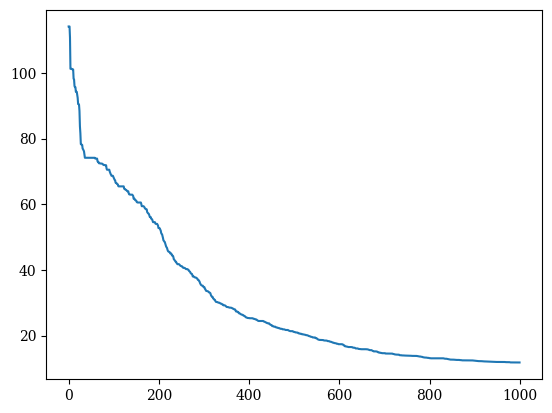

In [21]:
plt.plot(app)

iter. 	| func-value 	| residuum 	| sing-vec-error
100 	|  1.144e+01 	|  5.622e+00 	|  6.531e-02
||A|| =  11.443567013215626
iter. 	| func-value 	| residuum 	| sing-vec-error
100 	|  1.242e+01 	|  4.645e+00 	|  4.369e-02
||A|| =  12.420053846621062
iter. 	| func-value 	| residuum 	| sing-vec-error
100 	|  1.352e+01 	|  3.545e+00 	|  3.998e-01
||A|| =  13.5200847845554
iter. 	| func-value 	| residuum 	| sing-vec-error
100 	|  1.403e+01 	|  3.037e+00 	|  4.126e-02
||A|| =  14.028126585657414
iter. 	| func-value 	| residuum 	| sing-vec-error
100 	|  1.147e+01 	|  4.978e+00 	|  5.488e-02
||A|| =  11.465608011703349
iter. 	| func-value 	| residuum 	| sing-vec-error
100 	|  1.346e+01 	|  2.980e+00 	|  3.274e-01
||A|| =  13.462726823978935
iter. 	| func-value 	| residuum 	| sing-vec-error
100 	|  1.389e+01 	|  2.556e+00 	|  5.123e-02
||A|| =  13.887110087137861
iter. 	| func-value 	| residuum 	| sing-vec-error
100 	|  1.354e+01 	|  2.907e+00 	|  3.965e-02
||A|| =  13.535813674327162
iter. 	| f

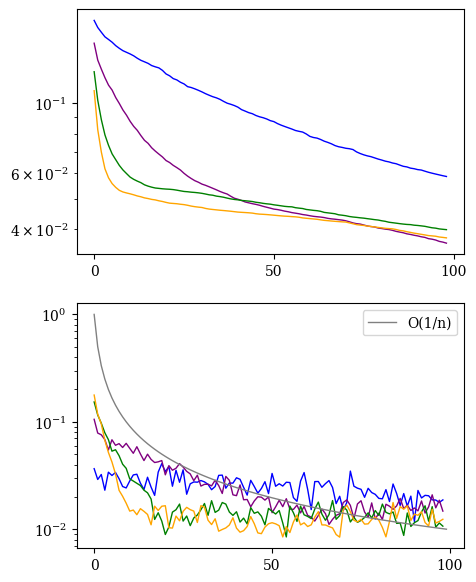

In [25]:
# for l in range(50):
fig, axs = plt.subplots(2, 1, figsize=(5,7), gridspec_kw={'height_ratios': [2, 2]})

l = 1

average_vu_1 = np.zeros(l*100+1)
average_bc_1 = np.zeros(l*100)
average_app_1 = np.zeros(l*100)
average_vu_10 = np.zeros(l*100+1)
average_bc_10 = np.zeros(l*100)
average_app_10 = np.zeros(l*100)
average_vu_50 = np.zeros(l*100+1)
average_bc_50 = np.zeros(l*100)
average_app_50 = np.zeros(l*100)
average_vu_100 = np.zeros(l*100+1)
average_bc_100 = np.zeros(l*100)
average_app_100 = np.zeros(l*100)

for k in range(10):
    m = 100
    p = 50
    A = np.random.randn(m,p)
    V = np.random.randn(p,m)
    V = np.zeros((p,m))
    vu_sol_o = np.max(np.linalg.svdvals(A - V.T))
    _, _, vu_sol_1, _, _, vuval_1, _, _, listbc_uv_1, _, _, _, listapprox2min_1, _ = adjointfreenorm.ZeroOrderMatFreeAdjOpNormDouble(A, V, iter=l*100, eps=1e-7, show=0,  k=1)
    _, _, vu_sol_10, _, _, vuval_10, _, _, listbc_uv_10, _, _, _, listapprox2min_10, _ = adjointfreenorm.ZeroOrderMatFreeAdjOpNormDouble(A, V, iter=l*100, eps=1e-7, show=0,  k=10)
    _, _, vu_sol_50, _, _, vuval_50, _, _, listbc_uv_50, _, _, _, listapprox2min_50, _ = adjointfreenorm.ZeroOrderMatFreeAdjOpNormDouble(A, V, iter=l*100, eps=1e-7, show=0,  k=50)
    _, _, vu_sol_100, _, _, vuval_100, _, _, listbc_uv_100, _, _, _, listapprox2min_100, _ = adjointfreenorm.ZeroOrderMatFreeAdjOpNormDouble(A, V, iter=l*100, eps=1e-7, show=0,  k=100)
    #axs[0].plot((vu_sol_o-np.abs(nA))/vu_sol_o, linewidth=0.2, c='b')
    average_vu_1 += np.abs(vu_sol_o-vuval_1)/vu_sol_o
    average_bc_1 += np.abs(listbc_uv_1)
    #average_app_1 += np.abs(listapprox2min_1)
    average_vu_10 += np.abs(vu_sol_o-vuval_10)/vu_sol_o
    average_bc_10 += np.abs(listbc_uv_10)
    #average_app_10 += np.abs(listapprox2min_10)
    average_vu_50 += np.abs(vu_sol_o-vuval_50)/vu_sol_o
    average_bc_50 += np.abs(listbc_uv_50)
    #average_app_50 += np.abs(listapprox2min_50)
    average_vu_100 += np.abs(vu_sol_o-vuval_100)/vu_sol_o
    average_bc_100 += np.abs(listbc_uv_100)
    #average_app_100 += np.abs(listapprox2min_100)

axs[0].semilogy(average_vu_1[1:l*100]/50, linewidth=1, c='b')
axs[0].semilogy(average_vu_10[1:l*100]/50, linewidth=1, c='purple')
axs[0].semilogy(average_vu_50[1:l*100]/50, linewidth=1, c='g')
axs[0].semilogy(average_vu_100[1:l*100]/50, linewidth=1, c='orange')
#axs[0].semilogy(average_cvu[1:100]/50, linewidth=1, c='gray',linestyle='-.',alpha=0.25)
axs[1].semilogy(average_bc_1[1:l*100]/50/10, linewidth=1, c='b')
axs[1].semilogy(average_bc_10[1:l*100]/50/10, linewidth=1, c='purple')
axs[1].semilogy(average_bc_50[1:l*100]/50/10, linewidth=1, c='g')
axs[1].semilogy(average_bc_100[1:l*100]/50/10, linewidth=1, c='orange')
axs[1].semilogy(1/np.linspace(1,100,l*100), linewidth=1, c='gray', label='O(1/n)')
axs[1].legend(loc="upper right")
#axs[2].semilogy(average_app_1[1:l*100]/50/10, linewidth=1, c='b')
#axs[2].semilogy(average_app_10[1:l*100]/50/10, linewidth=1, c='purple')
#axs[2].semilogy(average_app_50[1:l*100]/50/10, linewidth=1, c='g')
#axs[2].semilogy(average_app_100[1:l*100]/50/10, linewidth=1, c='orange')
#axs[2].semilogy(1/np.linspace(1,100,l*100), linewidth=1, c='gray', label='O(1/n)')
#axs[2].legend(loc="upper right")
plt.rc('font', family='serif')
plt.setp(axs, xticks=[0, 50, 100], xticklabels=['0', '50', '100'])
# plt.rc('font', family='serif')
# plt.savefig('gaussian_matrices_average_10_comp_all.pdf', dpi=100)
plt.show()

In [10]:
np.savetxt('average_vu_comp_100_50_1.csv', average_vu_1, delimiter=',')
np.savetxt('average_vu_comp_100_50_10.csv', average_vu_10, delimiter=',')
np.savetxt('average_vu_comp_100_50_50.csv', average_vu_50, delimiter=',')
np.savetxt('average_vu_comp_100_50_100.csv', average_vu_100, delimiter=',')
np.savetxt('average_bc_comp_100_50_1.csv', average_bc_1, delimiter=',')
np.savetxt('average_bc_comp_100_50_10.csv', average_bc_10, delimiter=',')
np.savetxt('average_bc_comp_100_50_50.csv', average_bc_50, delimiter=',')
np.savetxt('average_bc_comp_100_50_100.csv', average_bc_100, delimiter=',')


In [8]:
average_vu_1 = np.loadtxt('average_vu_comp_100_50_1.csv')
average_vu_10 = np.loadtxt('average_vu_comp_100_50_10.csv')
average_vu_50 = np.loadtxt('average_vu_comp_100_50_50.csv')
average_vu_100 = np.loadtxt('average_vu_comp_100_50_100.csv')

average_bc_1 = np.loadtxt('average_bc_comp_100_50_1.csv')
average_bc_10 = np.loadtxt('average_bc_comp_100_50_10.csv')
average_bc_50 = np.loadtxt('average_bc_comp_100_50_50.csv')
average_bc_100 = np.loadtxt('average_bc_comp_100_50_100.csv')

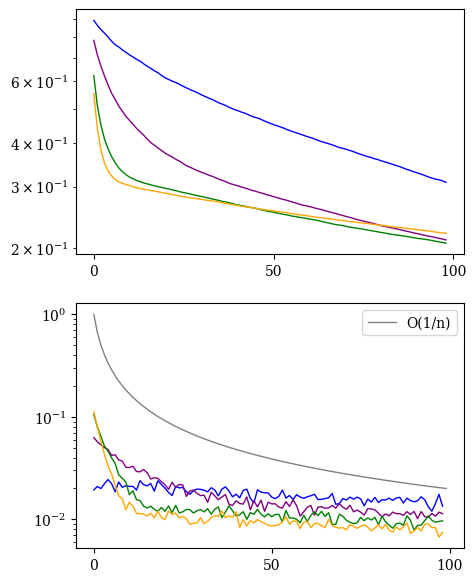

In [11]:
# for l in range(50):
l = 1
fig, axs = plt.subplots(2, 1, figsize=(5,7), gridspec_kw={'height_ratios': [2, 2]})
plt.rc('font', family='serif')
axs[0].semilogy(average_vu_1[1:l*100]/50, linewidth=1, c='b')
axs[0].semilogy(average_vu_10[1:l*100]/50, linewidth=1, c='purple')
axs[0].semilogy(average_vu_50[1:l*100]/50, linewidth=1, c='g')
axs[0].semilogy(average_vu_100[1:l*100]/50, linewidth=1, c='orange')
#axs[0].semilogy(average_cvu[1:100]/50, linewidth=1, c='gray',linestyle='-.',alpha=0.25)
axs[1].semilogy(average_bc_1[1:l*100]/50/100, linewidth=1, c='b')
axs[1].semilogy(average_bc_10[1:l*100]/50/100, linewidth=1, c='purple')
axs[1].semilogy(average_bc_50[1:l*100]/50/100, linewidth=1, c='g')
axs[1].semilogy(average_bc_100[1:l*100]/50/100, linewidth=1, c='orange')
axs[1].semilogy(1/np.linspace(1,50,l*100), linewidth=1, c='gray', label='O(1/n)')
axs[1].legend(loc="upper right")
#axs[2].semilogy(average_app_1[1:l*100]/50/10, linewidth=1, c='b')
#axs[2].semilogy(average_app_10[1:l*100]/50/10, linewidth=1, c='purple')
#axs[2].semilogy(average_app_50[1:l*100]/50/10, linewidth=1, c='g')
#axs[2].semilogy(average_app_100[1:l*100]/50/10, linewidth=1, c='orange')
#axs[2].semilogy(1/np.linspace(1,100,l*100), linewidth=1, c='gray', label='O(1/n)')
#axs[2].legend(loc="upper right")
plt.rc('font', family='serif')
plt.setp(axs, xticks=[0, 50, 100], xticklabels=['0', '50', '100'])
plt.savefig('gaussian_matrices_average_100_50_comp_all.pdf', dpi=100)
plt.show()